In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

In [2]:
(x_train, y_train), (x_test,y_test) = keras.datasets.mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
x_test.shape

(10000, 28, 28)

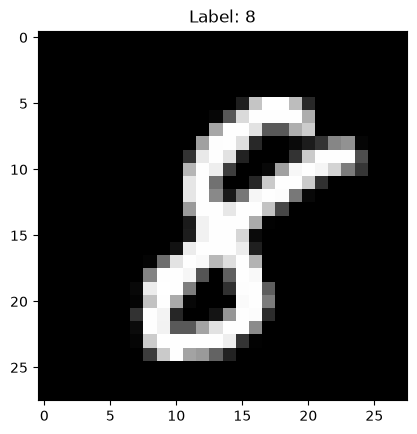

In [6]:
plt.imshow(x_train[571], cmap = 'grey')
plt.title(f"Label: {y_train[571]}")
plt.show()

In [7]:
x_train[571]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  31, 196, 254, 254, 188,  40,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [8]:
# data normalization

x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
# data flatening

flatened_x_train = x_train.reshape(-1,784)
flatened_x_test = x_test.reshape(-1,784)

In [10]:
flatened_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [11]:
# creating neural network

model = Sequential([
    Dense(256, activation = 'relu', input_shape = (784,)), Dropout(0.2),
    Dense(128, activation = 'relu'), Dropout(0.2),
    Dense(64, activation = 'relu'),
    Dense(10, activation = 'softmax')])
    

In [12]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [13]:
model.fit(flatened_x_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9211 - loss: 0.2621
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9628 - loss: 0.1224
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9710 - loss: 0.0939
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9769 - loss: 0.0765
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9786 - loss: 0.0671


In [14]:
model.evaluate(flatened_x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9791 - loss: 0.0708


[0.0708199068903923, 0.9790999889373779]

In [15]:
y_pred = model.predict(flatened_x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
y_pred[0]

array([1.0067217e-10, 1.1868119e-07, 2.1387514e-06, 8.9816403e-06,
       1.2964785e-10, 2.2090452e-08, 1.9983747e-13, 9.9998474e-01,
       9.9682920e-09, 4.0626142e-06], dtype=float32)

In [17]:
print(np.argmax(y_pred[0]))

7


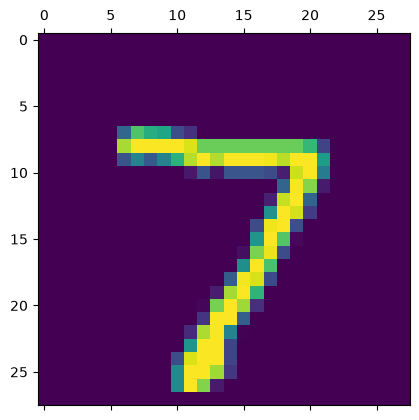

In [18]:
plt.matshow(x_test[0])

In [19]:
model.save("digit_recognition_model.keras")